# V2 Object Integration And DBSCAN Anchors

This notebook starts from the projected detections made by `v2_01_projection.ipynb`.

It first removes near-duplicate same-frame detections in memory, then learns static anchors with DBSCAN by label.


In [1]:
# load project paths and local v2 modules.
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import v2_config
from v2_02_object_integration import DEFAULT_DBSCAN_PARAMS_BY_LABEL, ObjectIntegrationSettings, anchor_learning_decision, run_v2_object_integration

v2_config.ensure_v2_output_dirs()
PROJECT_ROOT


PosixPath('/Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom')

In [2]:
# define v2 integration inputs and outputs.
PROJECTED_CSV = v2_config.V2_PROJECTED_DETECTIONS_CSV
INTEGRATED_CSV = v2_config.V2_INTEGRATED_OBJECTS_CSV
REGISTRY_CSV = v2_config.V2_STATIC_OBJECT_REGISTRY_CSV
LAYOUT_PREVIEW_PNG = v2_config.V2_DBSCAN_LAYOUT_PREVIEW_PNG
OUTLIER_SUMMARY_PNG = v2_config.V2_DBSCAN_OUTLIER_SUMMARY_PNG

print('projected input:', PROJECTED_CSV)
print('integrated output:', INTEGRATED_CSV)
print('registry output:', REGISTRY_CSV)


projected input: /Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/v2/projection/v2_projected_detections.csv
integrated output: /Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/v2/integration/v2_integrated_objects.csv
registry output: /Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/v2/integration/v2_static_object_registry.csv


In [3]:
# inspect projected detections from v2_01.
projected_df = pd.read_csv(PROJECTED_CSV)
print(f'projected rows: {len(projected_df):,}')
print('columns:', list(projected_df.columns))
display(projected_df.head())
display(projected_df['label'].value_counts().rename_axis('label').reset_index(name='rows'))


projected rows: 219,335
columns: ['image_name', 'timestamp', 'timestamp_valid', 'detection_index', 'label', 'bbox_x0', 'bbox_y0', 'bbox_x1', 'bbox_y1', 'temp_mean_c', 'temp_max_c', 'pixels', 'confidence', 'projected_x', 'projected_y']


,image_name,timestamp,timestamp_valid,detection_index,label,bbox_x0,bbox_y0,bbox_x1,bbox_y1,temp_mean_c,temp_max_c,pixels,confidence,projected_x,projected_y
0,IR_63142.jpg,2025-05-01 15:19:00,Y,1,Machine,531,298,553,318,21.886789,25.424925,106,0.822366,8.726787,3.638916
1,IR_63142.jpg,2025-05-01 15:19:00,Y,2,Machine,537,256,561,280,22.069757,25.502478,174,0.854753,8.075858,3.783144
2,IR_63142.jpg,2025-05-01 15:19:00,Y,3,Machine,474,248,508,271,21.645502,23.766699,194,0.834977,7.393746,3.656946
3,IR_63142.jpg,2025-05-01 15:19:00,Y,4,Machine,486,212,505,230,22.321835,25.575266,72,0.773920,6.418335,3.631017
4,IR_63142.jpg,2025-05-01 15:19:00,Y,5,Machine,522,207,577,248,23.885866,25.676907,925,0.903655,6.499782,3.895448


,label,rows
0,Machine,126359
1,Light,57408
2,Screen,14852
3,Window,11995
4,Person,8721


## Settings

`FRAME_IOU_THRESHOLD` removes duplicate detections in the original image: same image, same label, and bbox IoU above the threshold are merged by keeping the higher-confidence bbox.

`DBSCAN_PARAMS_BY_LABEL` learns static anchors after projection. `eps` is the neighbor distance in meters, and `min_samples` is the minimum local point count needed to form a cluster.


In [4]:
# configure same-frame image-bbox duplicate removal and DBSCAN anchor learning.
FRAME_IOU_THRESHOLD = 0.4  # bbox IoU threshold for same-image duplicate removal.
TRACK_PERSON = False  # keep person rows as frame-level detections.

DBSCAN_PARAMS_BY_LABEL = {
    'Machine': {'eps': 0.15, 'min_samples': 110},
    'Light': {'eps': 0.2, 'min_samples': 200},
    'Screen': {'eps': 0.6, 'min_samples': 100},
    'Window': {'eps': 0.3, 'min_samples': 50},
}

# general rule is applied before label-specific rules.
DBSCAN_GENERAL_RULE = {
    'max_x': 12.0,
    'max_y': 5.5,
}

# label-specific rules are applied after the general rule.
DBSCAN_LABEL_RULES_BY_LABEL = {
    'Machine': {
        'allowed_regions': [
            ('middle_block', 2.5, 2.8, 11.5, 4.0),
            ('lower_block', 2.0, 0.0, 12.0, 0.5),
            ('left_block', 0.0, 0.5, 1.5, 6.0),
        ],
    },
    'Screen': {
        'allowed_regions': [
            ('middle_block', 2.5, 2.8, 11.5, 4.0),
            ('lower_block', 2.0, 0.0, 12.0, 0.5),
            ('left_block', 0.0, 0.5, 1.5, 6.0),
        ],
    },
}

LABEL_COLORS = {
    'Machine': 'red',
    'Light': 'orange',
    'Screen': 'blue',
    'Window': 'green',
}

# print('same-frame duplicate removal settings:')
# display(pd.DataFrame([{
#     'bbox_iou_threshold': FRAME_IOU_THRESHOLD,
#     'track_person': TRACK_PERSON,
# }]))

# print('DBSCAN parameters:')
# display(pd.DataFrame([
#     {'label': label, **params}
#     for label, params in DBSCAN_PARAMS_BY_LABEL.items()
# ]))

# print('DBSCAN general rule:')
# display(pd.DataFrame([DBSCAN_GENERAL_RULE]))

# print('DBSCAN label-specific rules:')
# display(pd.DataFrame([
#     {'label': label, 'allowed_regions': rule.get('allowed_regions', [])}
#     for label, rule in DBSCAN_LABEL_RULES_BY_LABEL.items()
# ]))


In [5]:
# run src/v2_02_object_integration.py::run_v2_object_integration.
# this stage reads projected detections, removes same-frame bbox duplicates, learns DBSCAN anchors, and writes the clean integrated CSV.

active_dbscan_params = pd.DataFrame([
    {'label': label, **params}
    for label, params in DBSCAN_PARAMS_BY_LABEL.items()
]).sort_values('label')

display(active_dbscan_params)

object_integration_settings = ObjectIntegrationSettings(
    input_csv=PROJECTED_CSV,
    output_csv=INTEGRATED_CSV,
    registry_csv=REGISTRY_CSV,
    layout_preview_png=LAYOUT_PREVIEW_PNG,
    outlier_summary_png=OUTLIER_SUMMARY_PNG,
    frame_iou_threshold=FRAME_IOU_THRESHOLD,
    track_person=TRACK_PERSON,
)

input_rows, deduped_rows, integrated_rows, registry_rows, outlier_summary = run_v2_object_integration(
    object_integration_settings,
    dbscan_params_by_label=DBSCAN_PARAMS_BY_LABEL,
    dbscan_general_rule=DBSCAN_GENERAL_RULE,
    dbscan_label_rules_by_label=DBSCAN_LABEL_RULES_BY_LABEL,
)

registry_df = pd.DataFrame(registry_rows)
integrated_df = pd.DataFrame(integrated_rows)
outlier_df = pd.DataFrame(outlier_summary)

print('called: src/v2_02_object_integration.py::run_v2_object_integration')
print(f'input rows from v2_01 projection CSV: {len(input_rows):,}')
print(f'rows after same-frame duplicate filtering: {len(deduped_rows):,}')
print(f'rows written to integrated objects CSV: {len(integrated_rows):,}')
print(f'learned static anchors written to registry CSV: {len(registry_rows):,}')
print(f'integrated CSV: {INTEGRATED_CSV}')
print(f'registry CSV: {REGISTRY_CSV}')

if not registry_df.empty:
    registry_param_check = (
        registry_df[['label', 'dbscan_eps', 'dbscan_min_samples']]
        .drop_duplicates()
        .sort_values(['label', 'dbscan_eps', 'dbscan_min_samples'])
    )
    print('DBSCAN parameters written into registry:')
    display(registry_param_check)

if not outlier_df.empty:
    print('DBSCAN anchor and outlier summary from this run:')
    display(outlier_df.sort_values('label'))


,label,eps,min_samples
1,Light,0.20,200
0,Machine,0.15,110
2,Screen,0.60,100
3,Window,0.30,50


called: src/v2_02_object_integration.py::run_v2_object_integration
input rows from v2_01 projection CSV: 219,335
rows after same-frame duplicate filtering: 219,335
rows written to integrated objects CSV: 219,335
learned static anchors written to registry CSV: 13
integrated CSV: /Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/v2/integration/v2_integrated_objects.csv
registry CSV: /Users/pck/TUe_AI_ES/2025_Q3/Team_Intership/2026_group_cleanroom/tmp/v2/integration/v2_static_object_registry.csv
DBSCAN parameters written into registry:


,label,dbscan_eps,dbscan_min_samples
0,Light,0.200000,200
4,Machine,0.150000,110
10,Screen,0.600000,100
12,Window,0.300000,50


DBSCAN anchor and outlier summary from this run:


,label,rows,anchor_training_rows,anchor_rule_excluded_rows,anchors,dbscan_noise_rows,dbscan_noise_ratio,dbscan_eps,dbscan_min_samples
0,Light,57408,47696,9712,4,523,0.010965,0.20,200
1,Machine,126359,105422,20937,6,1456,0.013811,0.15,110
2,Screen,14852,1247,13605,2,25,0.020048,0.60,100
3,Window,11995,11995,0,1,2,0.000167,0.30,50


In [6]:
# inspect generated anchors and DBSCAN outlier counts.
# this cell reloads the clean CSV files without creating duplicate label columns.
registry_df = pd.read_csv(REGISTRY_CSV)
integrated_df = pd.read_csv(INTEGRATED_CSV)
outlier_df = pd.DataFrame(outlier_summary)

registry_param_check = (
    registry_df[['label', 'dbscan_eps', 'dbscan_min_samples']]
    .drop_duplicates()
    .sort_values(['label', 'dbscan_eps', 'dbscan_min_samples'])
)

anchor_count_check = (
    registry_df.groupby('label', dropna=False)
    .size()
    .reset_index(name='anchors')
    .sort_values('label')
)

integrated_object_counts = (
    integrated_df[integrated_df['label'].str.lower() != v2_config.PERSON_LABEL]
    .groupby(['label', 'object_id'], dropna=False)
    .size()
    .reset_index(name='rows')
    .sort_values(['label', 'object_id'])
)

display(registry_param_check)
display(anchor_count_check)
display(registry_df.sort_values(['label', 'object_id']))
display(outlier_df.sort_values('dbscan_noise_rows', ascending=False))
display(integrated_object_counts.head(30))


,label,dbscan_eps,dbscan_min_samples
0,Light,0.20,200
4,Machine,0.15,110
10,Screen,0.60,100
12,Window,0.30,50


,label,anchors
0,Light,4
1,Machine,6
2,Screen,2
3,Window,1


,object_id,label,anchor_x,anchor_y,observations,first_seen,last_seen,dbscan_eps,dbscan_min_samples
0,light_1,Light,2.565493,0.939902,26126,2025-04-23 14:29:00,2025-05-15 12:19:00,0.20,200
1,light_2,Light,6.453370,1.775548,13585,2025-04-23 14:29:00,2025-05-15 12:19:00,0.20,200
2,light_3,Light,8.058769,3.694192,3693,2025-04-23 14:29:00,2025-05-15 08:53:00,0.20,200
3,light_4,Light,10.635485,3.755376,3769,2025-04-23 14:29:00,2025-05-15 08:53:00,0.20,200
4,machine_1,Machine,9.789152,0.241733,322,2025-04-23 17:21:00,2025-05-15 10:48:00,0.15,110
5,machine_2,Machine,6.712124,0.311429,12470,2025-04-23 14:29:00,2025-05-15 12:18:00,0.15,110
6,machine_3,Machine,1.256375,0.800275,6435,2025-04-23 17:22:00,2025-05-15 10:53:00,0.15,110
7,machine_4,Machine,4.016633,2.938567,5222,2025-04-23 14:29:00,2025-05-15 12:19:00,0.15,110
8,machine_5,Machine,5.981587,2.946810,163,2025-04-24 09:16:00,2025-05-15 10:48:00,0.15,110
9,machine_6,Machine,7.788640,3.706367,79354,2025-04-23 14:29:00,2025-05-15 12:19:00,0.15,110


,label,rows,anchor_training_rows,anchor_rule_excluded_rows,anchors,dbscan_noise_rows,dbscan_noise_ratio,dbscan_eps,dbscan_min_samples
1,Machine,126359,105422,20937,6,1456,0.013811,0.15,110
0,Light,57408,47696,9712,4,523,0.010965,0.20,200
2,Screen,14852,1247,13605,2,25,0.020048,0.60,100
3,Window,11995,11995,0,1,2,0.000167,0.30,50


,label,object_id,rows
0,Light,light_1,26128
1,Light,light_2,13934
2,Light,light_3,3787
3,Light,light_4,13559
4,Machine,machine_1,4009
5,Machine,machine_2,12911
6,Machine,machine_3,23114
7,Machine,machine_4,6195
8,Machine,machine_5,240
9,Machine,machine_6,79890


## Projection Variation Check

Measure how far each projected detection is from its assigned anchor.


In [7]:
# calculate projection variation from each detection to its assigned anchor.
import numpy as np

variation_df = integrated_df[integrated_df['label'].str.lower() != v2_config.PERSON_LABEL].copy()
for col in ['projected_x', 'projected_y', 'anchor_x', 'anchor_y']:
    variation_df[col] = pd.to_numeric(variation_df[col], errors='coerce')
variation_df = variation_df.dropna(subset=['projected_x', 'projected_y', 'anchor_x', 'anchor_y'])

variation_df['dx_m'] = variation_df['projected_x'] - variation_df['anchor_x']
variation_df['dy_m'] = variation_df['projected_y'] - variation_df['anchor_y']
variation_df['variation_m'] = np.sqrt(variation_df['dx_m'] ** 2 + variation_df['dy_m'] ** 2)

variation_summary = (
    variation_df.groupby(['object_id', 'label'], dropna=False)['variation_m']
    .agg(count='count', median='median', p90=lambda s: s.quantile(0.90), p95=lambda s: s.quantile(0.95), max='max')
    .reset_index()
    .sort_values('p95', ascending=False)
)

display(variation_summary.head(30))


,object_id,label,count,median,p90,p95,max
4,machine_1,Machine,4009,3.883297,4.075468,4.096066,4.503673
9,machine_6,Machine,79890,1.188660,2.699735,2.976028,4.045549
5,machine_2,Machine,12911,0.481549,1.728511,2.216013,2.735942
3,light_4,Light,13559,1.996440,2.080003,2.102328,2.485195
6,machine_3,Machine,23114,1.089910,1.780373,1.958060,2.764843
10,screen_1,Screen,868,0.134889,0.887279,1.711642,4.153534
7,machine_4,Machine,6195,0.111677,1.268933,1.664596,2.716419
8,machine_5,Machine,240,0.107239,1.325421,1.360284,1.489604
11,screen_2,Screen,13984,0.661347,0.821685,1.195963,4.157879
0,light_1,Light,26128,0.600307,0.999291,1.149066,1.970817


## Projected Point Cloud Check

Show static-object projected points together with learned anchors. Person detections are excluded.


points shown: 210,614
anchors shown: 13


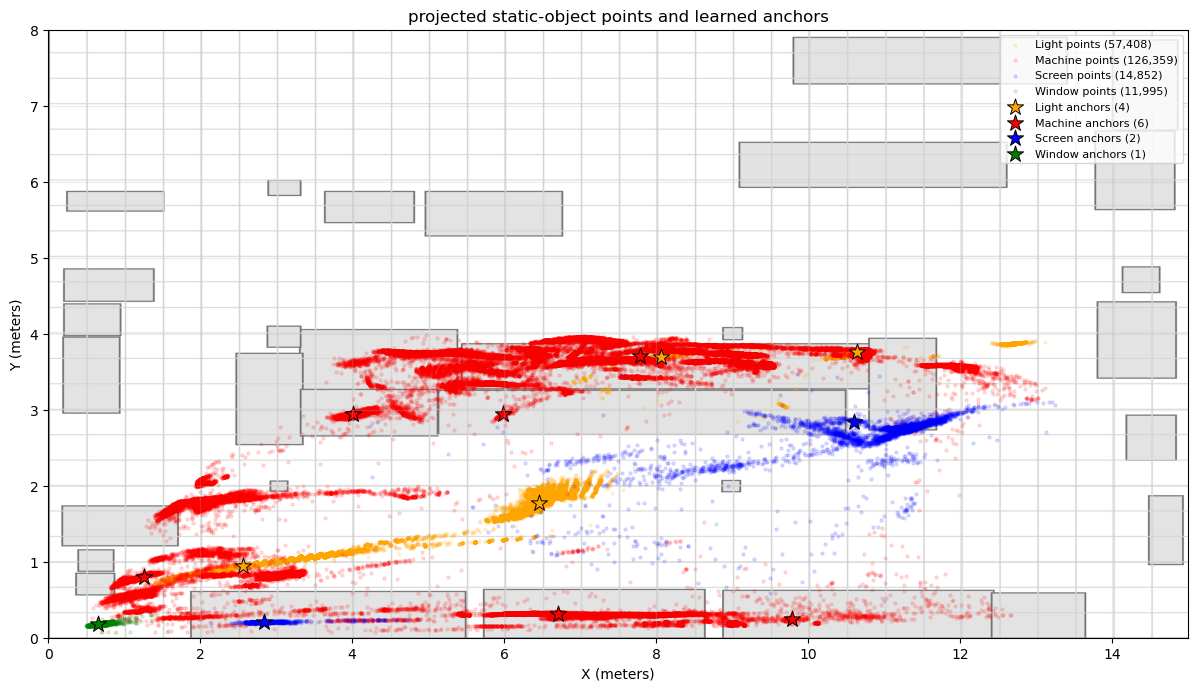

In [8]:
# plot static-object projected points and learned anchors. Person detections are excluded.
point_cloud_df = variation_df.copy()

anchor_cloud_df = registry_df.copy()
anchor_cloud_df = anchor_cloud_df[anchor_cloud_df['label'].str.lower() != v2_config.PERSON_LABEL].copy()
anchor_cloud_df['anchor_x'] = pd.to_numeric(anchor_cloud_df['anchor_x'], errors='coerce')
anchor_cloud_df['anchor_y'] = pd.to_numeric(anchor_cloud_df['anchor_y'], errors='coerce')
anchor_cloud_df = anchor_cloud_df.dropna(subset=['anchor_x', 'anchor_y'])

layout_img = plt.imread(v2_config.LAYOUT_IMAGE)

fig, ax = plt.subplots(figsize=(13, 7))
ax.imshow(
    layout_img,
    extent=[0, v2_config.MAP_WIDTH, 0, v2_config.MAP_HEIGHT],
    origin='upper',
    alpha=0.55,
)

for label, group in point_cloud_df.groupby('label'):
    ax.scatter(
        group['projected_x'],
        group['projected_y'],
        s=5,
        alpha=0.12,
        color=LABEL_COLORS.get(label, 'gray'),
        label=f'{label} points ({len(group):,})',
    )

for label, group in anchor_cloud_df.groupby('label'):
    ax.scatter(
        group['anchor_x'],
        group['anchor_y'],
        s=150,
        marker='*',
        color=LABEL_COLORS.get(label, 'gray'),
        edgecolor='black',
        linewidth=0.7,
        label=f'{label} anchors ({len(group):,})',
    )

ax.set_xlim(0, v2_config.MAP_WIDTH)
ax.set_ylim(0, v2_config.MAP_HEIGHT)
ax.set_xlabel('X (meters)')
ax.set_ylabel('Y (meters)')
ax.set_title('projected static-object points and learned anchors')
ax.grid(alpha=0.25)
ax.legend(loc='best', fontsize=8)
fig.tight_layout()

print(f'points shown: {len(point_cloud_df):,}')
print(f'anchors shown: {len(anchor_cloud_df):,}')
display(fig)
plt.close(fig)


## Anchor Assignment After Outlier Reassignment

Show the final assignment after DBSCAN noise points have been assigned to the nearest same-label anchor.

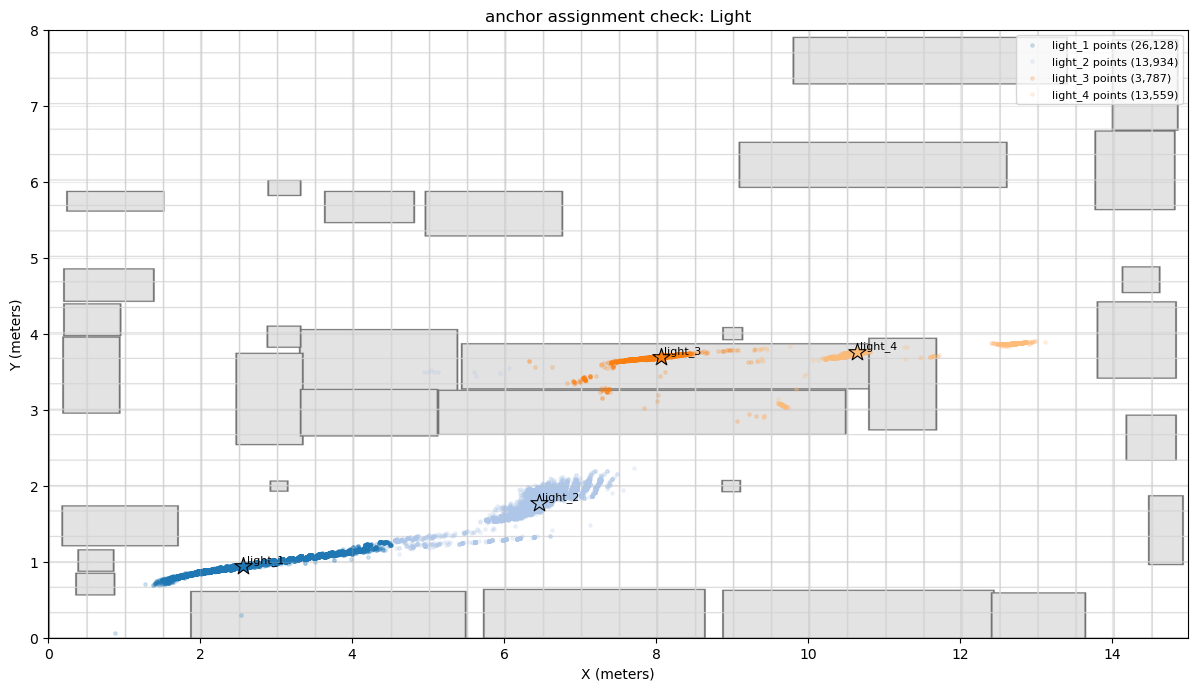

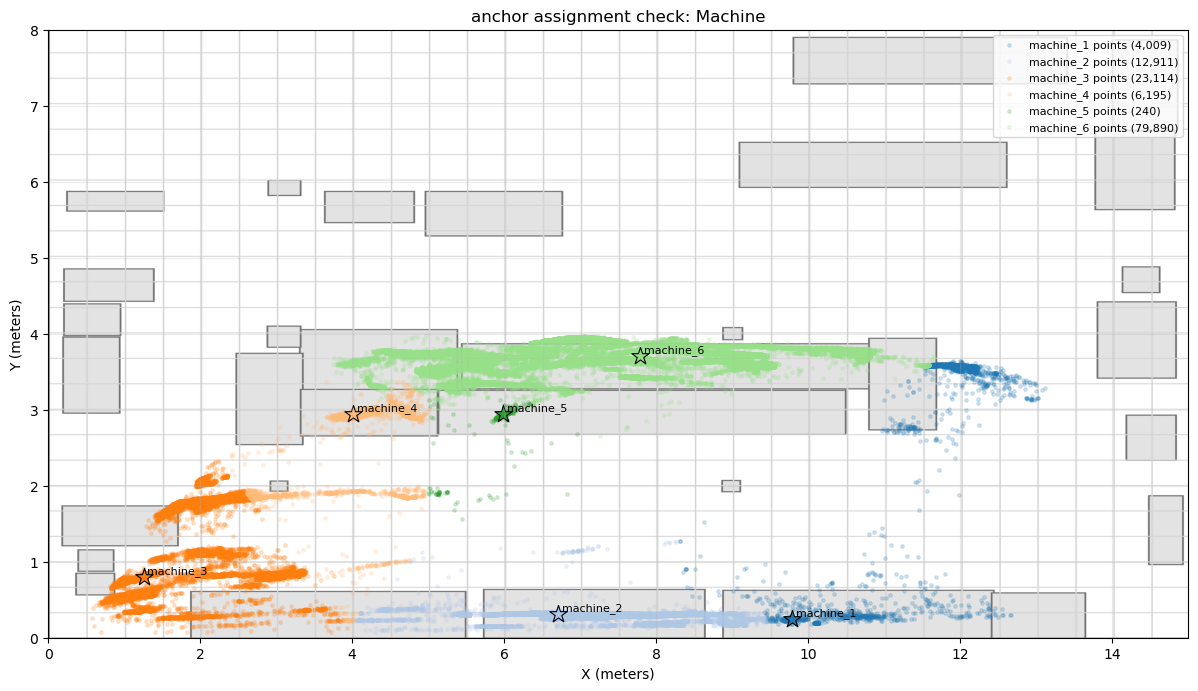

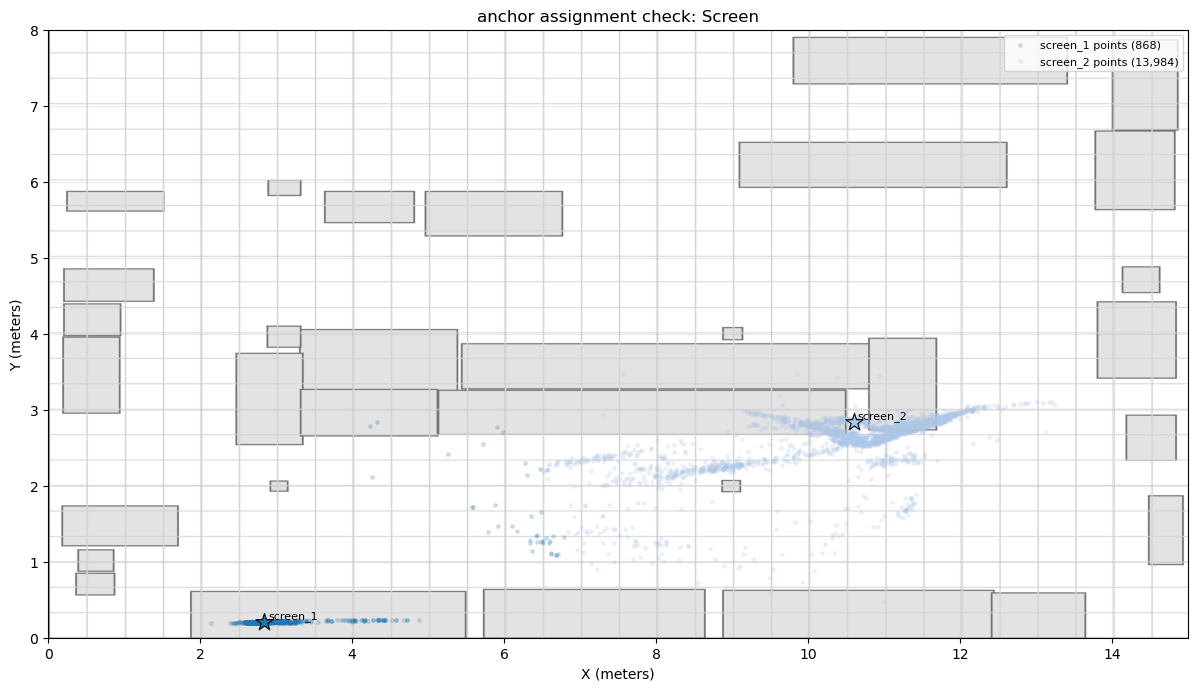

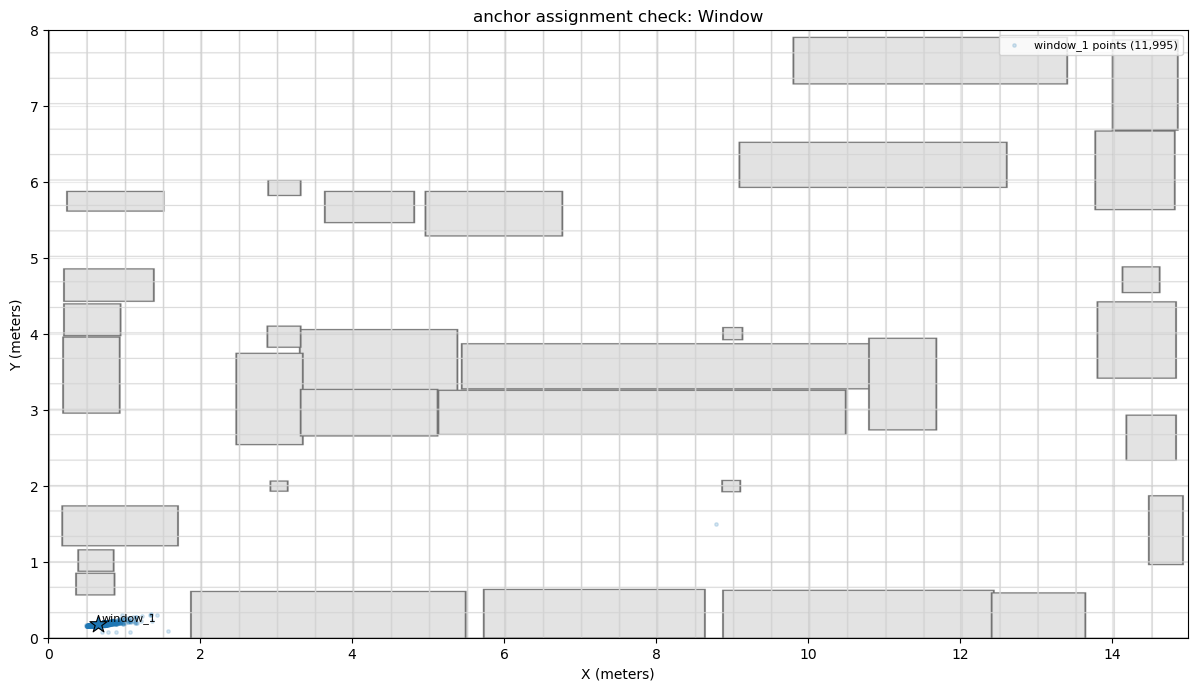

In [9]:
# plot assigned static-object points by object_id. Person detections are excluded.
assignment_df = integrated_df[integrated_df['label'].str.lower() != v2_config.PERSON_LABEL].copy()
for col in ['projected_x', 'projected_y', 'anchor_x', 'anchor_y']:
    assignment_df[col] = pd.to_numeric(assignment_df[col], errors='coerce')
assignment_df = assignment_df.dropna(subset=['projected_x', 'projected_y', 'anchor_x', 'anchor_y'])

assignment_anchor_df = registry_df.copy()
assignment_anchor_df = assignment_anchor_df[assignment_anchor_df['label'].str.lower() != v2_config.PERSON_LABEL].copy()
assignment_anchor_df['anchor_x'] = pd.to_numeric(assignment_anchor_df['anchor_x'], errors='coerce')
assignment_anchor_df['anchor_y'] = pd.to_numeric(assignment_anchor_df['anchor_y'], errors='coerce')
assignment_anchor_df = assignment_anchor_df.dropna(subset=['anchor_x', 'anchor_y'])

layout_img = plt.imread(v2_config.LAYOUT_IMAGE)

for label, label_points in assignment_df.groupby('label'):
    label_anchors = assignment_anchor_df[assignment_anchor_df['label'] == label].copy()
    if label_points.empty:
        continue

    object_ids = sorted(label_points['object_id'].dropna().unique())
    color_map = plt.get_cmap('tab20')
    object_colors = {object_id: color_map(index % 20) for index, object_id in enumerate(object_ids)}

    fig, ax = plt.subplots(figsize=(13, 7))
    ax.imshow(
        layout_img,
        extent=[0, v2_config.MAP_WIDTH, 0, v2_config.MAP_HEIGHT],
        origin='upper',
        alpha=0.55,
    )

    for object_id, object_points in label_points.groupby('object_id'):
        ax.scatter(
            object_points['projected_x'],
            object_points['projected_y'],
            s=6,
            alpha=0.18,
            color=object_colors.get(object_id, 'gray'),
            label=f'{object_id} points ({len(object_points):,})',
        )

    for _, row in label_anchors.iterrows():
        ax.scatter(
            row['anchor_x'],
            row['anchor_y'],
            s=170,
            marker='*',
            color=object_colors.get(row['object_id'], 'black'),
            edgecolor='black',
            linewidth=0.8,
        )
        ax.text(row['anchor_x'] + 0.05, row['anchor_y'] + 0.05, row['object_id'], fontsize=8)

    ax.set_xlim(0, v2_config.MAP_WIDTH)
    ax.set_ylim(0, v2_config.MAP_HEIGHT)
    ax.set_xlabel('X (meters)')
    ax.set_ylabel('Y (meters)')
    ax.set_title(f'anchor assignment check: {label}')
    ax.grid(alpha=0.25)
    ax.legend(loc='best', fontsize=8)
    fig.tight_layout()
    display(fig)
    plt.close(fig)


## Projection Variation Ranking By Object

Rank anchors by P95 variation to identify objects with unstable projected positions.


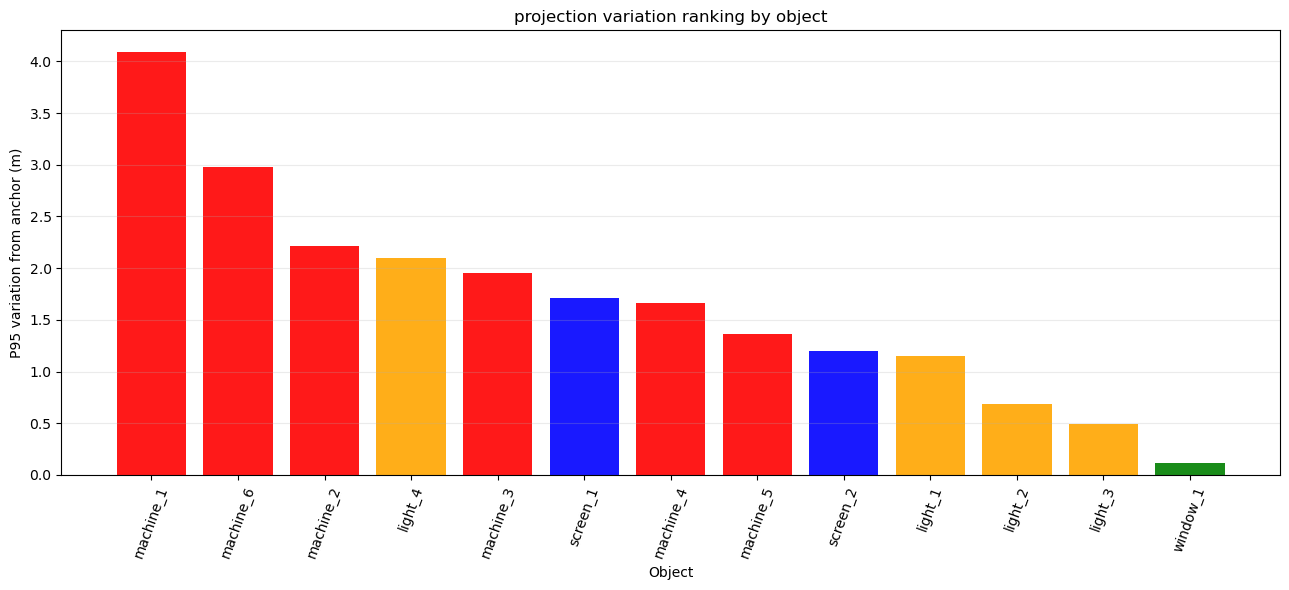

,object_id,label,median_variation_m,p90_variation_m,p95_variation_m
4,machine_1,Machine,3.883,4.075,4.096
9,machine_6,Machine,1.189,2.700,2.976
5,machine_2,Machine,0.482,1.729,2.216
3,light_4,Light,1.996,2.080,2.102
6,machine_3,Machine,1.090,1.780,1.958
10,screen_1,Screen,0.135,0.887,1.712
7,machine_4,Machine,0.112,1.269,1.665
8,machine_5,Machine,0.107,1.325,1.360
11,screen_2,Screen,0.661,0.822,1.196
0,light_1,Light,0.600,0.999,1.149


In [10]:
# plot p95 projection variation for each learned object and show the key comparison table.
# median shows typical error, p90 shows high spread, and p95 shows near-worst stable error.
plot_df = variation_summary.sort_values('p95', ascending=False).copy()
bar_colors = [LABEL_COLORS.get(label, 'gray') for label in plot_df['label']]

fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(plot_df['object_id'], plot_df['p95'], color=bar_colors, alpha=0.9)
ax.set_title('projection variation ranking by object')
ax.set_xlabel('Object')
ax.set_ylabel('P95 variation from anchor (m)')
ax.tick_params(axis='x', rotation=70)
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
display(fig)
plt.close(fig)

variation_table = plot_df[['object_id', 'label', 'median', 'p90', 'p95']].copy()
variation_table = variation_table.rename(columns={
    'median': 'median_variation_m',
    'p90': 'p90_variation_m',
    'p95': 'p95_variation_m',
})
for col in ['median_variation_m', 'p90_variation_m', 'p95_variation_m']:
    variation_table[col] = variation_table[col].round(3)

display(variation_table)


## Anchor Layout Check

Show only the final learned anchors on the cleanroom layout. Person detections are excluded.


anchors shown: 13


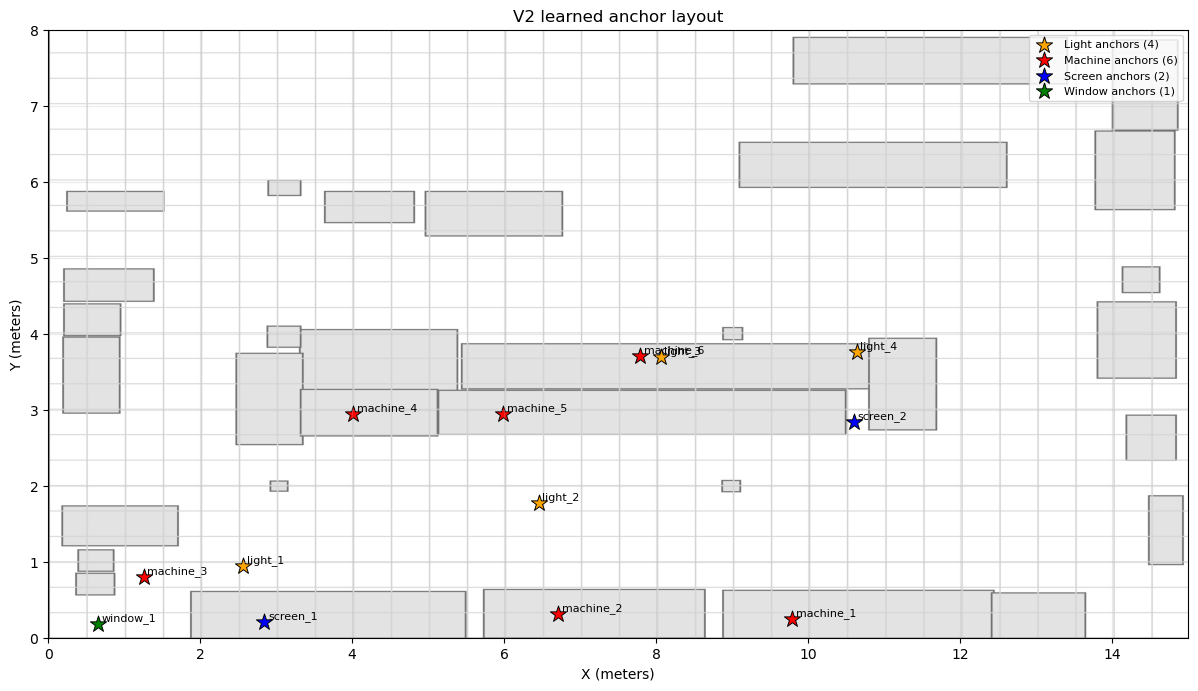

In [11]:
# plot learned anchors only. Person detections are excluded.
anchor_df = registry_df.copy()
anchor_df = anchor_df[anchor_df['label'] != 'Person'].copy()
anchor_df['anchor_x'] = pd.to_numeric(anchor_df['anchor_x'], errors='coerce')
anchor_df['anchor_y'] = pd.to_numeric(anchor_df['anchor_y'], errors='coerce')
anchor_df = anchor_df.dropna(subset=['anchor_x', 'anchor_y'])

layout_img = plt.imread(v2_config.LAYOUT_IMAGE)

fig, ax = plt.subplots(figsize=(13, 7))
ax.imshow(
    layout_img,
    extent=[0, v2_config.MAP_WIDTH, 0, v2_config.MAP_HEIGHT],
    origin='upper',
    alpha=0.55,
)

for label, group in anchor_df.groupby('label'):
    ax.scatter(
        group['anchor_x'],
        group['anchor_y'],
        s=150,
        marker='*',
        color=LABEL_COLORS.get(label, 'gray'),
        edgecolor='black',
        linewidth=0.7,
        label=f'{label} anchors ({len(group):,})',
    )
    for _, row in group.iterrows():
        ax.text(
            row['anchor_x'] + 0.05,
            row['anchor_y'] + 0.05,
            row['object_id'],
            fontsize=8,
        )

ax.set_xlim(0, v2_config.MAP_WIDTH)
ax.set_ylim(0, v2_config.MAP_HEIGHT)
ax.set_xlabel('X (meters)')
ax.set_ylabel('Y (meters)')
ax.set_title('V2 learned anchor layout')
ax.grid(alpha=0.25)
ax.legend(loc='best', fontsize=8)
fig.tight_layout()

print(f'anchors shown: {len(anchor_df):,}')
display(fig)
plt.close(fig)


## Outlier Handling By Label

Summarize how DBSCAN outliers were handled after clustering.


In [12]:
# show DBSCAN outlier and anchor-rule counts by label from the current DBSCAN run.
# these are diagnostic counts, not columns written into the integrated object CSV.
if outlier_df.empty:
    print('No DBSCAN outlier summary available. Rerun the integration cell first.')
else:
    outlier_view = outlier_df.copy()
    outlier_view['dbscan_noise_share'] = outlier_view['dbscan_noise_rows'] / outlier_view['anchor_training_rows'].replace(0, pd.NA)
    outlier_view['anchor_rule_excluded_share'] = outlier_view['anchor_rule_excluded_rows'] / outlier_view['rows'].replace(0, pd.NA)
    display(
        outlier_view[[
            'label',
            'rows',
            'anchor_training_rows',
            'anchor_rule_excluded_rows',
            'anchors',
            'dbscan_noise_rows',
            'dbscan_noise_share',
            'anchor_rule_excluded_share',
            'dbscan_eps',
            'dbscan_min_samples',
        ]].sort_values('label')
    )


,label,rows,anchor_training_rows,anchor_rule_excluded_rows,anchors,dbscan_noise_rows,dbscan_noise_share,anchor_rule_excluded_share,dbscan_eps,dbscan_min_samples
0,Light,57408,47696,9712,4,523,0.010965,0.169175,0.20,200
1,Machine,126359,105422,20937,6,1456,0.013811,0.165695,0.15,110
2,Screen,14852,1247,13605,2,25,0.020048,0.916038,0.60,100
3,Window,11995,11995,0,1,2,0.000167,0.000000,0.30,50


## Object Assignment Debug

Check whether an object_id contains rows whose original label differs from the assigned canonical label.


In [13]:
# inspect row counts for each assigned static object.
debug_static = integrated_df[integrated_df['label'].str.lower() != v2_config.PERSON_LABEL].copy()

object_row_counts = (
    debug_static
    .groupby(['object_id', 'label'], dropna=False)
    .size()
    .reset_index(name='rows')
    .sort_values(['label', 'object_id'])
)

print(f"objects: {debug_static['object_id'].nunique()}")
display(object_row_counts.head(50))


objects: 13


,object_id,label,rows
0,light_1,Light,26128
1,light_2,Light,13934
2,light_3,Light,3787
3,light_4,Light,13559
4,machine_1,Machine,4009
5,machine_2,Machine,12911
6,machine_3,Machine,23114
7,machine_4,Machine,6195
8,machine_5,Machine,240
9,machine_6,Machine,79890
